In [1]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import scvelo as scv
import multivelo as mv

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')
from UTV_metrics import *

In [3]:
num_comps = 9


In [4]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'

In [5]:
celltype_name = 'cell_type'

In [6]:
adata_rna = anndata.read_h5ad(data_outdir+'adata_rna.h5ad')

In [7]:
SCV_result = anndata.read_h5ad(model_outdir+'scvelo_result.h5ad')
MV_result = anndata.read_h5ad(model_outdir+'multivelo_result.h5ad')
AA_result = anndata.read_h5ad(model_outdir+'archvelo_result.h5ad')

In [8]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)


# Velocity fields

In [9]:
celltype_name = 'cell_type'

In [10]:
sns.set(style = 'ticks', font_scale = 1.3)

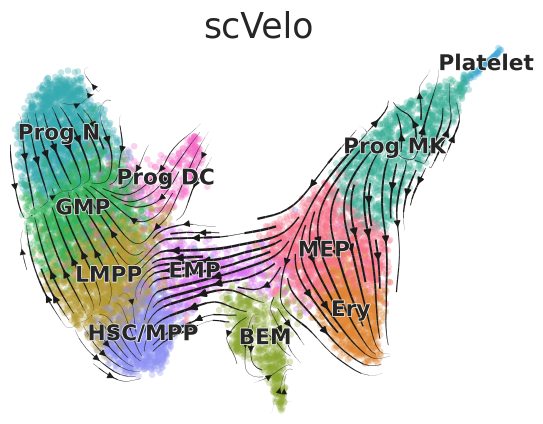

In [11]:
scv.pl.velocity_embedding_stream(SCV_result, 
                                 color = celltype_name,
                                 show = False,
                                 title = 'scVelo',
                                fontsize = 25)
plt.savefig(fig_outdir+'scVelo_results.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'scVelo_results.svg', dpi = 500, transparent = True)

computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:00:54) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 7 regions of root cells and 1 region of end points .
    finished (0:00:02) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:03) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


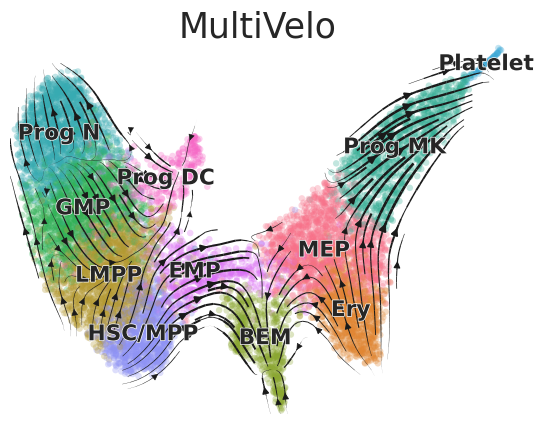

In [12]:
mv.velocity_graph(MV_result)
mv.latent_time(MV_result)
mv.velocity_embedding_stream(MV_result, 
                             show=False, 
                             color = celltype_name, 
                             title = 'MultiVelo',
                             fontsize = 25)
plt.savefig(fig_outdir+'MultiVelo_results.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'MultiVelo_results.svg', dpi = 500, transparent = True)

computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:01:24) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 8 regions of root cells and 1 region of end points .
    finished (0:00:03) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:08) --> added 
    'latent_time', shared time (adata.obs)
computing velocity embedding
    finished (0:00:03) --> added
    'velo_s_norm_umap', embedded velocity vectors (adata.obsm)


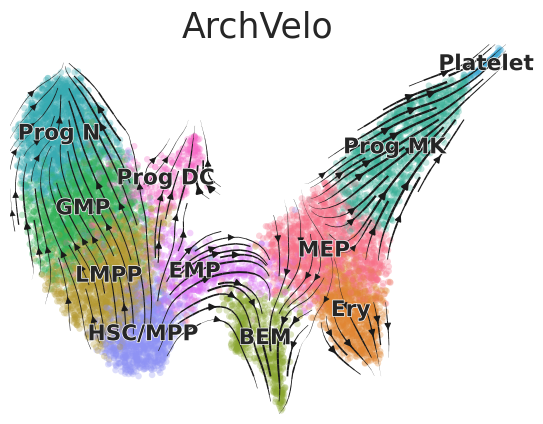

In [14]:
mv.velocity_graph(AA_result)
mv.latent_time(AA_result)
mv.velocity_embedding_stream(AA_result, 
                             show=False, 
                             color = celltype_name, 
                             title = 'ArchVelo',
                            fontsize = 25)
plt.savefig(fig_outdir+'AA_results.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'AA_results.svg', dpi = 500, transparent = True)

# CBD

In [15]:
inds = np.array([[i]+list(np.nonzero(x)[1]) for (i,x) in enumerate(adata_rna.obsp['distances'])])
SCV_result.uns['neighbors']['indices'] = inds
MV_result.uns['neighbors']['indices'] = inds
AA_result.uns['neighbors']['indices'] = inds

## finer notation

In [16]:
edges = [('HSC/MPP', 'LMPP'), 
         ('LMPP', 'GMP'),
         ('GMP', 'Prog N'), 
         ('LMPP', 'Prog DC'),    
         ('HSC/MPP', 'EMP'), 
         ('EMP', 'MEP'),
         ('EMP', 'BEM'),
         ('MEP', 'BEM'),
         ('MEP', 'Ery'),
         ('MEP', 'Prog MK'),
         ('Prog MK', 'Platelet')]
        

In [17]:
len(edges)

11

In [18]:
CBCs = {}

In [19]:
CBCs['scVelo'] = cross_boundary_correctness(
    SCV_result, 
    celltype_name, 
    'velocity', 
    edges, 
    x_emb="X_umap", return_raw = True)

In [20]:
CBCs['MultiVelo'] = cross_boundary_correctness(
    MV_result, 
    celltype_name, 
    'velo_s_norm', 
    edges, 
    x_emb="X_umap", return_raw = True)

In [21]:
CBCs['ArchVelo'] = cross_boundary_correctness(
    AA_result, 
    celltype_name, 
    'velo_s_norm', 
    edges, 
    x_emb="X_umap", return_raw = True)

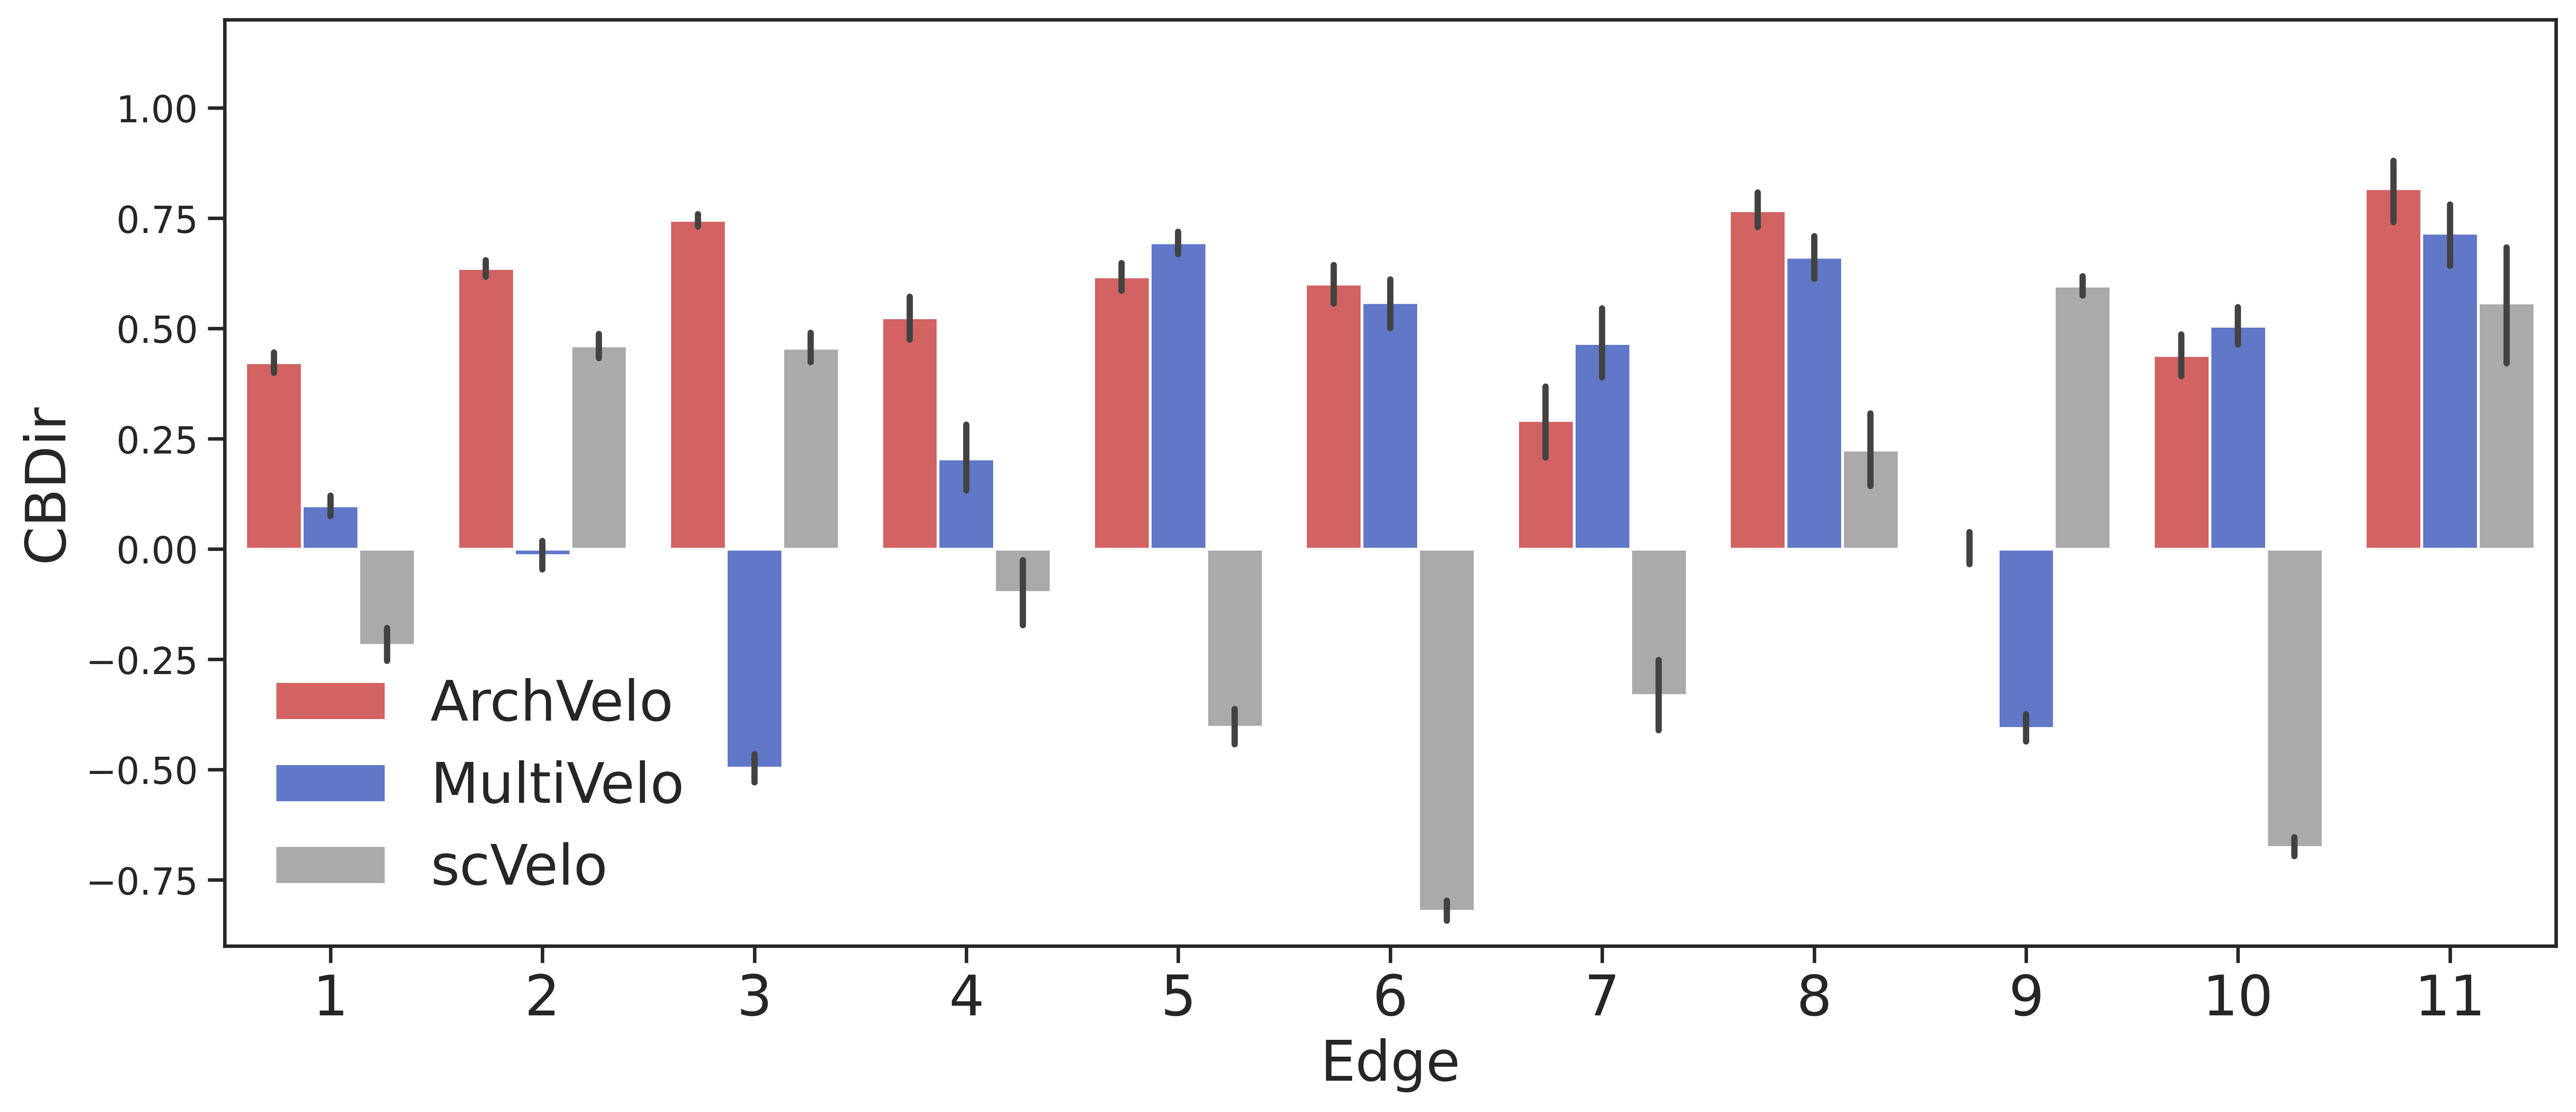

In [22]:
sns.set(style = 'ticks', font_scale = 1.2)
plt.figure(figsize = (15,6), dpi = 500)
methods = CBCs.keys()
all_CBCs = pd.concat([pd.concat([pd.Series(CBCs[met][k]) for k in CBCs[met].keys()],
         keys = [str(x[0]) for x in list(zip(CBCs[met].keys()))]) for met in methods],
          keys = methods, axis = 0, join = 'outer').reset_index()
all_CBCs.columns = ['Method', 'Edge', 'Cell','CBD']
sns.barplot(all_CBCs, 
            y = 'CBD',
            x = 'Edge',
            #order = edge_order,
            hue = 'Method', 
             palette = ['#E64F4F', '#506ED8', '#AAAAAA'],#palette = np.array(sns.color_palette('hls',4))[[0,2,3]], #swap_axes = True,
             hue_order = ['ArchVelo', 'MultiVelo', 'scVelo'])#, order = edges)
plt.xticks(ticks = range(len(edges)),labels = [str(x) for x in range(1,1+len(edges))],fontsize = 20)
plt.ylabel('CBDir', fontsize = 20)
plt.xlabel('Edge',fontsize = 20)
plt.legend(frameon = False, fontsize = 20)
plt.ylim(-0.9, 1.2)
plt.savefig(fig_outdir+'CBCs_with_CMP_no_MV_AA.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'CBCs_with_CMP_no_MV_AA.svg', dpi = 500, transparent = True)

In [23]:
from scipy.stats import wilcoxon, ttest_rel
i=0
for edge in edges:
    i+=1
    cur_df = all_CBCs.loc[all_CBCs['Edge'].isin([str(edge)]),:]
    xx = cur_df.query('Method == "ArchVelo"')['CBD']
    yy = cur_df.query('Method == "MultiVelo"')['CBD']
    #if np.abs(np.mean(xx)-np.mean(yy))>0.05:
    print('i=',i)
    print(edge)
    p = wilcoxon(x = xx, 
             y = yy,
             zero_method='wilcox').pvalue
    print(p)
    if p<0.01/len(edges):
        if np.mean(xx)> np.mean(yy):
            print('ArchVelo')
        else:
            print('MultiVelo')

i= 1
('HSC/MPP', 'LMPP')
3.2271668936581525e-162
ArchVelo
i= 2
('LMPP', 'GMP')
3.2703401981898244e-210
ArchVelo
i= 3
('GMP', 'Prog N')
1.2490008914156913e-207
ArchVelo
i= 4
('LMPP', 'Prog DC')
6.086480371112468e-12
ArchVelo
i= 5
('HSC/MPP', 'EMP')
1.505895723231508e-06
MultiVelo
i= 6
('EMP', 'MEP')
0.01928947406443134
i= 7
('EMP', 'BEM')
4.4405454716220154e-11
MultiVelo
i= 8
('MEP', 'BEM')
2.054269956962067e-09
ArchVelo
i= 9
('MEP', 'Ery')
2.1215965381598465e-91
ArchVelo
i= 10
('MEP', 'Prog MK')
0.0421135819572674
i= 11
('Prog MK', 'Platelet')
7.319306280667348e-09
ArchVelo


In [24]:
from scipy.stats import wilcoxon, ttest_rel
i=0
for edge in edges:
    i+=1
    cur_df = all_CBCs.loc[all_CBCs['Edge'].isin([str(edge)]),:]
    xx = cur_df.query('Method == "ArchVelo"')['CBD']
    yy = cur_df.query('Method == "scVelo"')['CBD']
    #if np.abs(np.mean(xx)-np.mean(yy))>0.05:
    print('i=',i)
    print(edge)
    p = wilcoxon(x = xx, 
             y = yy,
             zero_method='wilcox').pvalue
    print(p)
    if p<0.01/len(edges):
        if np.mean(xx)> np.mean(yy):
            print('ArchVelo')
        else:
            print('scVelo')

i= 1
('HSC/MPP', 'LMPP')
9.890884901275927e-75
ArchVelo
i= 2
('LMPP', 'GMP')
4.858472294380877e-15
ArchVelo
i= 3
('GMP', 'Prog N')
2.877659279171341e-39
ArchVelo
i= 4
('LMPP', 'Prog DC')
9.496945513763532e-27
ArchVelo
i= 5
('HSC/MPP', 'EMP')
1.7362888729839246e-77
ArchVelo
i= 6
('EMP', 'MEP')
1.618599905335437e-70
ArchVelo
i= 7
('EMP', 'BEM')
2.5849873714504004e-15
ArchVelo
i= 8
('MEP', 'BEM')
6.104370495956221e-22
ArchVelo
i= 9
('MEP', 'Ery')
3.2212628164974517e-94
scVelo
i= 10
('MEP', 'Prog MK')
2.551114945361327e-97
ArchVelo
i= 11
('Prog MK', 'Platelet')
0.000739638689106586
ArchVelo
